# Assignment 5: US midterm issues, sentiment, sweep odds and a mid-term basket

This notebook reproduces every table and figure in `REPORT.pdf`. It does not pull data itself: the collectors and scorers are `scripts/01` to `07`, and they write to `data/`. The first code cell re-runs `scripts/08_run_analysis.py` (all tables and `outputs/results.json`) and `scripts/09_make_figures.py` (all figures) on the saved data, so everything shown below is computed here, the same way as for the report.

Each section below starts with the report's own text for that section (copied from `REPORT.md` when the notebook is built), and then shows the tables behind it. After each figure block there is a short "How these figures are made" cell.

In [1]:
import sys, json, warnings, subprocess
sys.path.insert(0, '.'); sys.path.insert(0, 'scripts')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option('display.width', 180); pd.set_option('display.max_columns', 30)
from src.config import TABLES, FIGURES, OUTPUTS, PREREG, PREREG_DEVIATION
# recompute every table and figure from the saved data, exactly as for the report
for s in ['scripts/08_run_analysis.py', 'scripts/09_make_figures.py']:
    r = subprocess.run([sys.executable, s], capture_output=True, text=True)
    print(s, 'exit', r.returncode)
    assert r.returncode == 0, r.stderr[-2000:]
R = json.loads((OUTPUTS / 'results.json').read_text())
print('key topics:', R['q1']['key_topics'])

scripts/08_run_analysis.py exit 0


scripts/09_make_figures.py exit 0
key topics: ['Foreign policy & Iran war', 'Democracy & rule of law', 'Abortion & social issues', 'Immigration & deportations', 'Taxes, budget & spending', 'Health care', 'Trump & the administration', 'Government ethics & corruption']


# Assignment 5 report

### US Midterm Issues, Sentiment, Democratic Sweep Odds and a Mid-Term Basket: Jul 1 to Oct 7, 2026

FRE-GY 7871 A · NLP and the Investment Process

**Name:** Aditya Gupta
**NetID:** ag11023
**GitHub repo:** https://github.com/Aditya-Gupta26/FRE_GY_7871_Assignment_5

---

## 1. What I did

The midterms are on Nov 3, 2026. Republicans hold the White House, the House (218 R, 214 D, 1 I) and the Senate (53 R, 47 D incl. 2 independents), so a "Democratic sweep" needs a net gain of 3 House seats and 4 Senate seats (VP Vance breaks a 50-50 tie). The question asks which issues voters care about, whether sentiment on those issues tracks the odds of a sweep on Polymarket and Kalshi, and whether a basket of stocks exposed to the result moves with that sentiment. My window is Jul 1 to the Oct 7 close (99 calendar days, 69 trading days), because the report is due Oct 10.

**Data.** From social media I collected **31,540 tweets** (twitterapi.io, $4.48 charged) and, in addition to Twitter, also **143,625 Reddit posts and comments** from six political subreddits (Arctic Shift); after the filters 25,743 tweets and 40,148 Reddit items are left. From the news side, **72,688 unique election headlines** from 30 named outlets (Google News RSS). The sweep odds are the Polymarket "Democrats Sweep" contract and the Kalshi `KXBALANCEPOWERCOMBO-27FEB-DD` contract, hourly, snapshotted at 16:00 ET. Prices for 27 stocks and 10 ETFs or futures come from yfinance. I ran BERTopic with an LLM (Claude subagents) naming the issues, built a validated directional index (+ = more pro-Democrat or anti-GOP), ran pre-registered tests against the daily change in the odds, and fixed a 17-name basket before seeing any test-window return.

**Table 1. Event calendar (ET; all checked against news sources)**

| Date | Event |
|---|---|
| Feb 28; Jul 24; Sept 2 | Iran war starts (ongoing); Section 301 tariffs replace lapsed Section 122 tariffs; funding to Dec 11 signed (no Oct 1 shutdown) |
| Sept 13 (Sun) | Polymarket sweep odds jump 49.5% to 53.5%; start of the repricing |
| Sept 15 to 16 | NYT/Siena poll D 51 to 43; CLARITY Act fails cloture 49 to 50; Fed raises rates 25bp (first hike since 2023) |
| Sept 21 to 23 | Reuters/Ipsos Trump approval 32%; Cook shifts GA, KS, SC toward D |

**Short answers.**
- **Q1 (issues):** in voters' own posts foreign policy leads (20.3% of issue talk, mostly Israel aid and the Iran war) and democracy and rule of law is second (11.7%), in every seed of the model; immigration, taxes, health care and ethics follow. The economy and cost of living gets 6.2% (6% to 9% across seeds), while polls put it first (22% to 31%) and news covers it far more (14.8%).
- **Q2 (sentiment module):** a directional index validated against blind labels (best tool macro-F1 0.59, κ 0.38). It works per document but is mostly noise as a daily series (split-half r 0.08 on average).
- **Q3 (sweep odds):** no. None of the 7 pre-registered tests passes (smallest BH q 0.31); the few low p-values have the opposite sign and are no more than chance across the robustness checks.
- **Q4 (basket):** the basket has the right sign over the window (+6.3% market-adjusted), but day to day it does not move with the sweep odds (r 0.03) or with the sentiment index.
- **Q5:** voters' agenda is measurable from text and differs from both polls and media; but daily text sentiment does not lead the sweep odds or the stocks in this window.

## 2. Data

- **Twitter/X** (twitterapi.io): one query on midterms, Congress, the parties, "vote blue/red" and House or Senate races, `lang:en -filter:retweets min_faves:5`; one page (max 20 tweets, Latest order, so the last 1 to 2 minutes) per 90-minute window, 1,584 windows, i.e. 16 short snapshots a day. A probe showed 51% of `min_faves:2` tweets pass the views rule against 95% at `min_faves:5`, so I used 5.
- **Reddit, in addition to Twitter** (Arctic Shift archive): r/politics, r/Conservative, r/democrats, r/Republican, r/PoliticalDiscussion and r/moderatepolitics. Every post, plus the first 50 comments of each 6-hour window.
- **News** (Google News RSS, `site:` queries, election query only): 30 outlets in Sacerdote-style groups, US left 7 (CNN, MS NOW, NYT...), US right 6 (Fox, NY Post, Breitbart...), US centre 9 (AP, Reuters, Politico...), business 4 and international 4 (full list in the README). A feed returns at most 100 items; capped 2-day windows were re-pulled by day, but 352 of 445 stay capped, so each outlet-day is a relevance-ranked sample. Headlines carry a date only (75% stamped 07:00 GMT), so news is never used in a timed test.
- As discussed in class (and cleaned as in Bagheri and Yener: links and @users replaced, HTML unescaped), raw social posts are very noisy, so to keep the signal-to-noise ratio under control a post is kept only if it is inside the window, not removed or deleted, English, has **a US-politics term in the text itself**, has no spam or promo language, has 5+ words, passes an engagement rule (**tweets: 100+ views, 10+ followers, account 30+ days old; Reddit: score 2+**), is not a near duplicate (MinHash, Jaccard ≥ 0.8), and is one of at most 5 posts by that author that day. Out of 175,165 downloaded items, 65,891 survive. The politics-term rule removes the most (153,306 to 99,413), mostly short Reddit replies, then the engagement rule (98,192 to 67,559). Posts are then split into **voter voice** (comments, Reddit self-posts, tweets from non-media accounts: 45,278) and **shared media** (Reddit link posts, whose r/politics titles must be the exact headline, and news-account tweets: 20,613).
- **Prediction markets.** Polymarket's "Democrats Sweep" resolves on seat counts (independents count with their caucus; a 50-50 Senate goes to the Vice President's party); Kalshi's DD pays if the Speaker and the Senate President pro tempore are Democrats on Feb 1, 2027. Polymarket's price matched its order-book midpoint in a live check; Kalshi hourly candles mostly have no trade, so I use the bid/ask mid. Both were at 63.5% on Oct 7; the gap stays within -1.0 to +6.0 points (mean +1.7).
- **Equities** (yfinance): 27 candidates in 9 policy groups, plus SPY and sector or factor ETFs (ITA, XLV, IBIT, USO, ICLN, XRT). The Oct 7 close came from the last hourly bar, because Yahoo's daily bar was empty at pull time.

In [2]:
display(pd.read_csv(TABLES / 'filter_waterfall.csv'))
print(json.load(open(TABLES / 'news_corpus_counts.json')))
print('docs used in Q1:', R['q1']['n_docs'])

,step,reddit,twitter,total
0,0 downloaded,143625,31540,175165
1,1 inside Jun 30 16:00 to Oct 7 16:00 ET,143625,31540,175165
2,2 not removed or deleted,121928,31540,153468
3,3 English (tweet lang; Reddit ascii share >= 0.8),121766,31540,153306
4,4 US-politics term in the text itself,69125,30288,99413
5,5 no spam or promo language,69103,30156,99259
6,6 at least 5 words,68259,29933,98192
7,"7 engagement/account: tweets views>=100, follo...",41522,26037,67559
8,"8 no exact or near duplicate (MinHash, Jaccard...",40467,25747,66214
9,9 at most 5 docs per author per day,40148,25743,65891


{'downloaded': 173956, 'dated_in_window': 171816, 'unique_link': 77797, 'unique_title_per_site_4plus_words': 72688}
docs used in Q1: {'voter': 45278, 'voter_issue': 12567, 'shared_media': 20613, 'news': 72342, 'news_issue': 23045}


## 3. Method

- **Topic model.** BERTopic (Grootendorst 2022): MiniLM embeddings, UMAP (5 dims), HDBSCAN (min cluster 240 = 0.4% of a 60,001-doc sample stratified by day and source), c-TF-IDF words; fitted on social and news together, applied to all 138,579 docs. **Why BERTopic and not LDA** (the model in Bybee et al. 2024, the class reading on topic "attention"): our texts are tweets, comments and headlines, and on a 30k subsample BERTopic is more coherent at every seed (C_NPMI 0.065 to 0.071, C_V 0.52 to 0.53) than LDA at its best K = 10 (C_NPMI 0.0001, C_V 0.48). Over 3 seeds the doc assignments agree at ARI 0.59 to 0.63, and 6 or 7 of the 8 key issues recur each time.
- **The LLM step.** A Claude subagent with no context saw only each topic's top words and 5 example docs and mapped the 61 topics to 14 of the 16 allowed issues (none to political violence or energy) or to horse race, media or noise (34 issue topics, 27 non-issue; 37 high, 19 medium, 5 low confidence). India's Congress-party topic (3,803 docs, 93% tweets matching "Congress") went to noise. Against separate blind issue labels on the 150 validation items, topic plus taxonomy matches on 72% of the 85 items the model assigns.
- **Direction tools.** Plain tone does not say which party gains, so each tool gives a direction score s in [-1, 1]: (1) zero-shot NLI (Laurer et al. 2023), s = P(pro-D hypothesis) - P(pro-R hypothesis); (2) target-signed Twitter-RoBERTa, s = (P_pos - P_neg) x τ, τ = +1 if only Democrat-side names appear, -1 if only GOP-side names (Trump, MAGA, Vance...); (3) target-signed VADER; (4) an LLM-distilled logistic regression on the embeddings, trained on 1,500 subagent labels; (5) plain RoBERTa tone as the non-directional baseline.
- **Validation.** 150 items (60 tweets, 50 Reddit, 40 headlines, 2/3 of them naming a party side) were labelled blind by a fresh Claude subagent that saw only the guide and the text, not any score. **These are LLM labels, not human labels.** A second subagent relabelled 50 calibration items: κ = 0.96 (98% agreement).

**Table 2. Direction validation, macro-F1 [95% bootstrap CI] (κ)**

| Text | NLI | RoBERTa x τ | VADER x τ | LLM-distilled |
|---|---|---|---|---|
| Tweets (60) | **0.59** [0.46, 0.71] (0.40) | 0.54 (0.35) | 0.48 (0.25) | 0.55 (0.35) |
| Reddit (50) | 0.47 (0.16) | **0.58** [0.39, 0.73] (0.32) | 0.47 (0.21) | 0.39 (0.10) |
| Headlines (40) | 0.29 (0.03) | 0.47 (0.38) | 0.43 (0.29) | 0.48 (0.38) |
| All (150) | 0.54 (0.29) | 0.59 [0.49, 0.68] (0.38) | 0.48 (0.26) | 0.53 (0.33) |

*Why this result:* NLI reads the stance of a whole sentence, which helps on tweets that attack a side without naming the other; target-signing works where the text names one party (on Reddit), but it gives 0 to the 60% of Reddit posts that name neither or both. The distilled tool scored 0.63 in cross-validation on its own labels but only 0.53 here, so it learned the labeller more than the stance. Tone (RoBERTa macro-F1 0.71, κ 0.62; VADER 0.48) is much easier than direction.

- **Which score is used where, and why.** Tweets: **NLI** (DeBERTa-v3 trained on MNLI, ANLI, WANLI and other inference sets plus synthetic data), the best on tweets (0.59), since it needs no party name. Reddit: **target-signed RoBERTa** (cardiffnlp, trained on about 124M tweets), the best on Reddit (0.58). The CIs overlap, so the choice is by point estimate, with a pre-set rule that the distilled tool cannot win a tie (it is graded by the same kind of labeller it learned from); since the same 150 items pick the tool and score it, the chosen tool's F1 is a bit optimistic. RoBERTa-only and tone-only indices are robustness checks. Headlines are not in the index (no time of day).
- **The index** (pre-registered at 20:45 ET on Oct 7, construction details added at 21:28 ET, both before any index existed). Voter-voice docs only. For issue k, source g (Twitter and each subreddit) and day t: the mean s, demeaned within issue and source over the window (so r/Conservative's permanent lean adds nothing, only its day-to-day moves), averaged over sources with fixed doc-share weights: I_k,t. The composite is C_t = Σ w_k I_k,t / Σ w_k, with w_k the Q1 voter shares of the 8 key issues. Expected sign: **C_t up goes with the sweep odds up**. *Deviation, disclosed:* the pre-registered rule needed 20 docs per issue-day on 90% of days, and no issue reached it (best 69%), so for the index docs use the outlier-reduced topic assignment and a minimum of 5 docs (decided at 21:50 ET on doc counts only, before any index or test).
- **Timing.** Day t is [16:00 ET on t-1, 16:00 ET on t) and the odds are snapshotted at the last hourly point at or before 16:05 ET (Polymarket's 16:00 point is stamped about 17 s past the hour); both are asserted in code. For stocks, weekends pool into Monday.
- **Tests.** Family A (pre-registered): the same-day relation of C_t with ΔP_t plus Granger tests at lags 1 to 3 in both directions, 7 tests, with Benjamini-Hochberg at q = 0.10 on HAC p-values (Newey-West, 5 lags for the same-day test and p lags for a lag-p Granger test). A claim needs the expected sign, BH q < 0.10, a circular-shift permutation p < 0.10, survival when any one day is dropped and survival when Sept 10 to 26 is dropped. Day-of-week dummies are included. A robustness grid repeats this for Kalshi, the venue average, Δlogit, the trading-day calendar and seven other index versions (same-day test only for 3- and 5-day changes) (including the pre-registered 20-doc minimum); its hit count is judged against a joint null in which every index series is circularly shifted.

**Table 3. Formula register (each checked against its source)**

| Measure | Formula | Source |
|---|---|---|
| Issue share; agenda distance | docs in issue k / docs in any issue; TVD = ½ Σ_k abs(a_k - b_k) | Bybee et al. (2024); Levin, Peres and Wilmer (2009) §4.1 |
| Agreement; reliability | κ = (p_o - p_e)/(1 - p_e), macro-F1 = mean per-class F1; split-half 2r/(1+r) | Cohen (1960), scikit-learn; Spearman (1910), Brown (1910) |
| Sweep change; detectable r | ΔP_t = 100 (p_t - p_t-1); r* = tanh((z_.975 + z_.80)/√(N-3)) | Knight (2006), Snowberg et al. (2007); Hulley et al. (2013) |
| Granger; HAC; FDR | F = ((SSR_r - SSR_u)/q)/(SSR_u/df); Bartlett 1 - j/(m+1); largest k with p_(k) ≤ (k/m) q | Granger (1969); Newey and West (1987); Benjamini and Hochberg (1995) |
| Abnormal return; election beta | AR = R - α - βR_m (pre-window; test window α = 0); AR_t = a + γ ΔP_t + e | MacKinlay (1997) eq. 3, 7; Knight (2006) eq. 3 |
| Heteroskedasticity estimate | d = [Cov_H(ΔP,y) - Cov_L(ΔP,y)]/[Var_H(ΔP) - Var_L(ΔP)] | Rigobon and Sack (2003) eq. 10 |

In [3]:
print('pre-registration (written before any test):'); print(json.dumps(PREREG, indent=1))
print('disclosed deviation:'); print(json.dumps(PREREG_DEVIATION, indent=1))
print('topic model:', R['q1']['bertopic']); print('diagnostics:', json.dumps(R['q1']['diagnostics']['ari']))
display(pd.read_csv(TABLES / 'q1_lda_sweep.csv').round(4))
print('topic assignment vs blind issue labels:', R['q1']['topic_assignment_accuracy'])

pre-registration (written before any test):
{
 "primary_index": "C_t: social-only, issue-weighted, source-demeaned daily mean direction score",
 "primary_test": "C_t vs dP_t (Polymarket Democrats Sweep, 16:00 ET snapshots, calendar days)",
 "expected_sign_index_vs_dp": 1,
 "secondary_test": "dC_t vs dP_t",
 "stationarity_rule": "if C_t fails ADF (p>=0.05) or KPSS (p<=0.05), dC_t becomes primary",
 "family_A": "same-day corr + Granger lags 1-3 both directions (7 tests), BH q=0.10 on HAC p",
 "claim_rule": "expected sign AND BH-adjusted HAC p<0.10 AND permutation p<0.10 AND survives leave-one-day-out AND survives dropping Sept 10-26",
 "robustness": "Kalshi mid; venue average; 3- and 5-day overlapping changes (NW lags h-1); dlogit(p); expanding/equal/pooled weights; trading-day calendar",
 "null_meaning": "daily dP has low SNR (venues agree at r~0.4 daily), so a null means 'not detectable at a daily horizon in 99 days', not 'sentiment is irrelevant'",
 "basket_primary": "all names in str

,K,c_npmi,c_v
0,10,0.0001,0.4764
1,15,-0.0188,0.4712
2,20,-0.0694,0.4280
3,25,-0.0653,0.4414
4,30,-0.0915,0.3985


topic assignment vs blind issue labels: {'N': 150, 'strict_agree_all': 0.4066666666666667, 'n_non_outlier': 85, 'strict_agree_non_outlier': 0.7176470588235294, 'ro_agree_all': 0.64, 'label_is_issue_share': 0.4866666666666667}


**Which score is used where, and why (same as REPORT Section 3).** Tweets use zero-shot NLI, the best tool on the 60 validation tweets (macro-F1 0.59, κ 0.40), because it reads stance without needing a party name. Reddit uses target-signed Twitter-RoBERTa, the best on the 50 Reddit items (0.58, κ 0.32). Headlines are not in the index at all, because they have a date but no time. VADER and the distilled classifier are robustness or comparison tools only. The table below is the full validation.

In [4]:
v = pd.read_csv(TABLES / 'q2_validation.csv')
display(v.round(3))
print(json.dumps(R['q2']['validation_summary'], indent=1))

,task,tool,texts,N,macro_f1,f1_lo,f1_hi,kappa,kappa_lo,kappa_hi,accuracy
0,direction,nli,all,150,0.540,0.450,0.622,0.290,0.151,0.423,0.633
1,direction,nli,news,40,0.289,0.257,0.315,0.031,-0.143,0.222,0.725
2,direction,nli,reddit,50,0.466,0.286,0.631,0.163,-0.055,0.387,0.560
3,direction,nli,twitter,60,0.586,0.456,0.707,0.396,0.206,0.575,0.633
4,direction,rob_tgt,all,150,0.587,0.487,0.675,0.377,0.238,0.513,0.673
5,direction,rob_tgt,news,40,0.465,0.296,0.586,0.375,-0.057,0.724,0.825
6,direction,rob_tgt,reddit,50,0.582,0.388,0.727,0.324,0.078,0.545,0.620
7,direction,rob_tgt,twitter,60,0.544,0.401,0.673,0.354,0.163,0.542,0.617
8,direction,vad_tgt,all,150,0.484,0.396,0.566,0.257,0.130,0.378,0.587
9,direction,vad_tgt,news,40,0.433,0.277,0.553,0.285,0.005,0.569,0.725


{
 "nli_seconds_for_1650_docs": 250.0,
 "distilled_cv_on_calibration": {
  "N": 1500,
  "macro_f1": 0.6341234260860936,
  "f1_lo": 0.6070922855215675,
  "f1_hi": 0.6603138648205874,
  "kappa": 0.46065428824049515,
  "kappa_lo": 0.4234909534653824,
  "kappa_hi": 0.4983981811428849,
  "accuracy": 0.6746666666666666
 },
 "interlabeller_direction": {
  "N": 50,
  "kappa": 0.9640546369518332,
  "agreement": 0.98
 },
 "label_counts_validation": {
  "N": 91,
  "D": 35,
  "R": 24
 },
 "label_counts_calibration": {
  "N": 879,
  "D": 395,
  "R": 226
 },
 "tau_nonzero_share_validation": 0.5333333333333333
}


## 4. Q1: Which issues do voters care most about?

*Readings used:* Bybee, Kelly, Manela and Xiu (2024) for topic shares as "attention"; Sacerdote, Sehgal and Cook (2020) for comparing outlet groups.

![Figure 1](outputs/figures/fig1_issue_shares.png)
*Figure 1. Share of issue docs per issue (horse race, media, noise and outliers excluded), Jul 1 to Oct 7. Blue: voter-voice posts (12,567 issue docs); orange: election headlines (23,045); green: Reuters/Ipsos Sept 17 to 20, registered voters (no bar: no such poll category). Issues under 2% in both text sources and not in the poll are not drawn (education 1.5%). From the BERTopic plus LLM taxonomy, no sentiment score; full topic table in the notebook. Descriptive.*

![Figure 2](outputs/figures/fig2_salience_over_time.png)
*Figure 2. Daily share of voter issue docs per key issue, 7-day mean, like the attention series in Bybee et al. Grey band: the Sept 10 to 26 repricing. Descriptive.*

**Result.** Yes, a clear ranking comes out, but it is not the polls' ranking. In voters' own posts **foreign policy leads (20.3%)**: Israel aid and AIPAC 9.5 points, the Iran war 6.9, Ukraine 2.6, China 0.9, Hormuz 0.5. Then democracy and rule of law (11.7%: mail voting, voter-fraud cases, the SAVE Act, the Supreme Court), abortion and social issues (11.5%), immigration and ICE (8.8%), taxes and budget (7.3%), health care (7.2%), Trump and his administration (6.6%) and government ethics (6.2%: PAC money, the Epstein files). These eight are the key topics (rule: share ≥ 5%, top 8). The **economy and cost of living is ninth at 6.2%, only 0.06 points behind ethics**, while Pew (29%), Gallup (31%) and Reuters/Ipsos (22%) all put it first. Robust: engagement weighting moves no share by more than 1.1 points, and in all 3 seeds foreign policy is first (21% to 31%), democracy second (13% to 16%), with immigration, taxes, health care and ethics in the top 8. Fragile: "abortion and social issues" is 11.1% in the main fit but 3% to 6% in the seeds, and is mostly race (609 of 1,446 docs, a low-confidence topic) and religion (348) debates, abortion and trans rights only 489; in every seed the economy (8% to 9%) takes its slot (and Tech and AI replaces Trump in 2 of 3), still far below the polls.
- Rank agreement with polls is weak and only descriptive (4 to 8 categories): Spearman ρ = 0.28 with Reuters/Ipsos, -0.70 with Pew and -1.0 with Gallup.
- Media and voters differ: news gives the economy 14.8% and "Tech and AI" 17.9% (much of it markets and CEO news), but social issues (race, religion, abortion) only 2.8% against voters' 11.5%.

*Against Bybee et al.:* they find WSJ attention has recurrent topics and emergent, event-driven ones. Here too: foreign policy is recurrent (its 7-day share never falls below 12.7%), while ethics is event-driven, from an August median of 5.4% to 13.3% on Sept 12, mostly the "taxpayer-funded ads and PAC money" topic (115 of 148 ethics posts in Sept 10 to 20).

*Why this result:* a poll asks people to pick one problem, and "the economy" is the easy answer; but people post about what is new or contested that day, and a war, court fights over voting and ICE raids give more to argue about than prices. Within the economy's 6.2%, gas and diesel prices are the biggest part (3.7 points). And posters are not a sample of registered voters.

**In short.** The text clearly shows what politically active people talk about, foreign policy (Israel, the Iran war) first and democracy second in every run, and it is not the economy-first list that polls give. Below the top two, the order moves with the model seed (social issues and the economy swap places), so only the broad picture is robust.

,topic,label,short_name,confidence,share_all_docs_%,top_words,example_1
27,27,Abortion & social issues,Abortion and trans rights,high,0.89,"abortion, trans, transgender, rights, sports, gender, lgbtq, care, men, womens","If that’s where the argument ended, maybe that reply would hold water. But the trans community faces [legislation](h..."
46,46,Abortion & social issues,Race and racism debates,low,0.54,"black, racist, women, white, democrats, racism, slavery, republicans, civil, men",@user @user Come to the Dark Side. Republicans are a multi ethnic coalition of free market pro growth capitalist fut...
54,54,Abortion & social issues,Religion and Muslims,medium,0.44,"religious, muslims, christian, muslim, religion, god, law, christians, islamic, church",Republicans are making Muslims a campaign issue in the 2026 US midterms
44,44,Crime & policing,Shootings and violent crime,medium,0.51,"shooting, police, killed, man, suspect, dead, shot, woman, murder, charged",Minneapolis Police-Involved Shooting With 'Multiple Victims': What We Know
23,23,Democracy & rule of law,Mail voting court fight,high,1.04,"mail, voting, court, supreme, supreme court, ballot, ballots, order, restrictions, judge",BREAKING: Supreme Court rejects Trump effort to restrict mail-in voting
...,...,...,...,...,...,...,...
29,29,Tech & AI,Data center backlash,medium,0.86,"data, data centers, centers, data center, center, backlash, costs, electricity, construction, energy",Data centers are Congress’ newest obsession
49,49,Tech & AI,Crypto CLARITY Act,medium,0.55,"crypto, clarity, act, sec, rules, ethics, market, digital, financial, trump",@user it hasn’t got the backing of the Democrats . Wise up while Trump and his family are involved in crypto they wi...
19,19,Trump & the administration,Kennedy Center and ballroom,medium,0.99,"kennedy, center, ballroom, white house, construction, white, trump, trumps, house, arch","Trump fights to keep name on Kennedy Center, warning demolition if renovations don't continue"
32,32,Trump & the administration,Hegseth Pentagon purge,medium,0.73,"hegseth, military, pentagon, pete, pete hegseth, war, secretary, army, defense, troops",Hegseth’s escalating purge is rocking the US military


,voter,voter_eng,voter_ro,voter_no_lowconf,voter_twitter,voter_reddit,shared_media,news,cov5_ro,news_US_LEFT,news_US_RIGHT,news_US_CENTER,news_BUSINESS,news_INTL
Foreign policy & Iran war,20.3,20.7,13.3,22.0,21.7,19.4,24.6,23.3,100.0,23.4,29.4,23.5,16.9,28.8
Democracy & rule of law,11.7,12.6,15.3,12.6,12.5,11.2,13.1,8.8,100.0,11.2,9.2,8.6,3.2,5.9
Abortion & social issues,11.5,12.0,10.7,7.2,14.9,9.1,5.4,2.8,100.0,2.9,7.2,2.1,0.3,3.0
Immigration & deportations,8.8,9.0,11.2,9.5,9.4,8.4,11.5,5.3,100.0,6.4,8.0,5.5,0.7,7.4
"Taxes, budget & spending",7.3,6.3,7.4,7.9,4.6,9.2,1.7,2.5,99.0,2.3,2.3,2.2,3.1,3.2
Health care,7.2,6.8,5.1,7.8,6.3,7.9,5.1,5.0,93.9,5.6,4.6,6.1,3.0,3.5
Trump & the administration,6.6,6.0,13.9,7.1,2.7,9.3,10.2,5.9,100.0,10.5,4.7,5.7,2.0,5.6
Government ethics & corruption,6.2,6.3,5.6,6.7,7.2,5.5,5.8,4.4,97.0,6.3,4.1,3.8,2.1,4.3
Economy & cost of living,6.2,6.1,4.6,6.7,5.9,6.4,5.7,14.8,86.9,9.9,8.2,16.0,26.9,14.4
Tech & AI,5.6,6.2,4.3,6.0,8.6,3.5,8.0,17.9,85.9,12.5,12.2,15.6,35.9,13.9


,poll,issue,poll_pct,voter_pct,news_pct,spearman_voter,spearman_news,n_categories
0,Pew Jul 2026 (RV),Economy & cost of living,29.0,6.17,14.79,-0.70,-0.32,6
1,Pew Jul 2026 (RV),Government ethics & corruption,9.0,6.23,4.37,-0.70,-0.32,6
2,Pew Jul 2026 (RV),Immigration & deportations,7.0,8.82,5.25,-0.70,-0.32,6
3,Pew Jul 2026 (RV),Health care,5.0,7.20,4.99,-0.70,-0.32,6
4,Pew Jul 2026 (RV),Foreign policy & Iran war,4.0,20.35,23.33,-0.70,-0.32,6
5,Pew Jul 2026 (RV),Trump & the administration,4.0,6.56,5.94,-0.70,-0.32,6
6,Gallup Sep 2026,Economy & cost of living,31.0,6.17,14.79,-1.00,-0.20,4
7,Gallup Sep 2026,Trump & the administration,30.0,6.56,5.94,-1.00,-0.20,4
8,Gallup Sep 2026,Immigration & deportations,10.0,8.82,5.25,-1.00,-0.20,4
9,Gallup Sep 2026,Foreign policy & Iran war,7.0,20.35,23.33,-1.00,-0.20,4


,main_fit,seed1,seed2,seed3
issue,,,,
Economy & cost of living,6.3,9.4,8.1,8.7
Tariffs & trade,4.1,3.0,2.8,2.6
"Taxes, budget & spending",7.5,7.7,7.4,11.1
Health care,7.3,7.7,7.4,6.9
Immigration & deportations,9.2,7.3,6.8,6.4
Foreign policy & Iran war,18.9,24.4,31.0,21.2
Democracy & rule of law,12.1,13.7,12.6,15.6
Government ethics & corruption,6.7,7.1,6.7,6.5
Trump & the administration,7.3,5.4,3.0,6.5


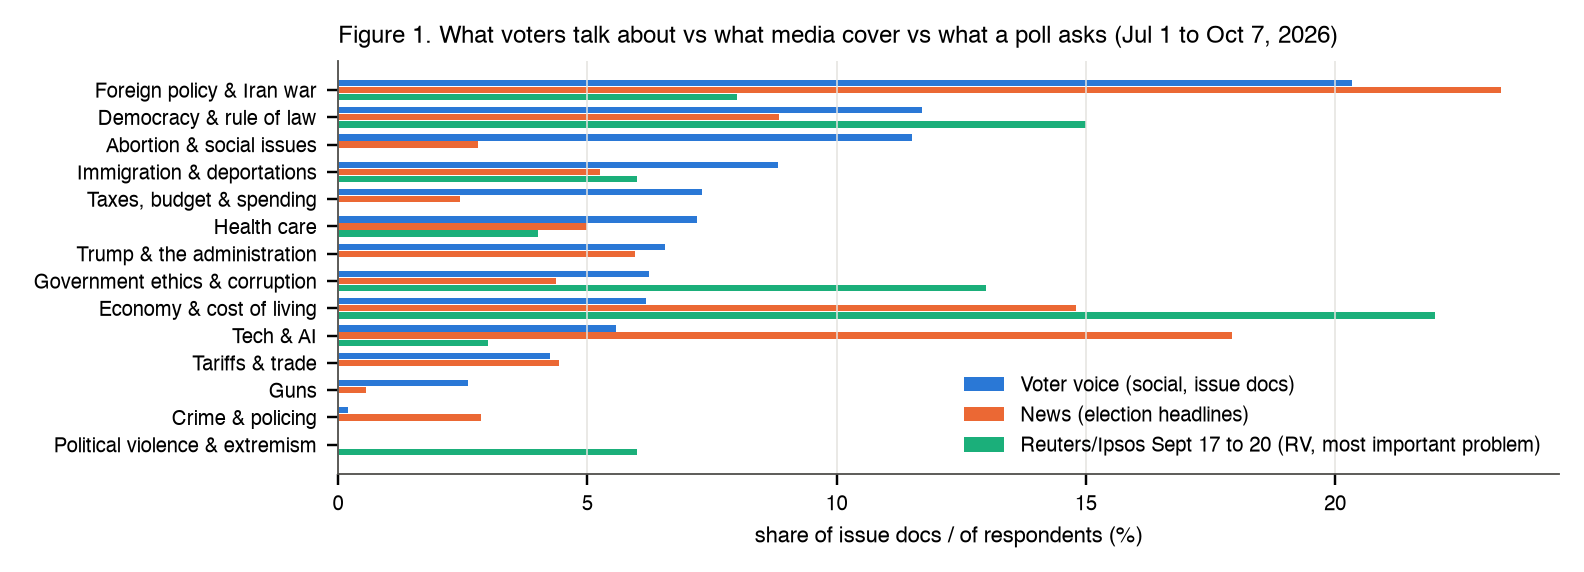

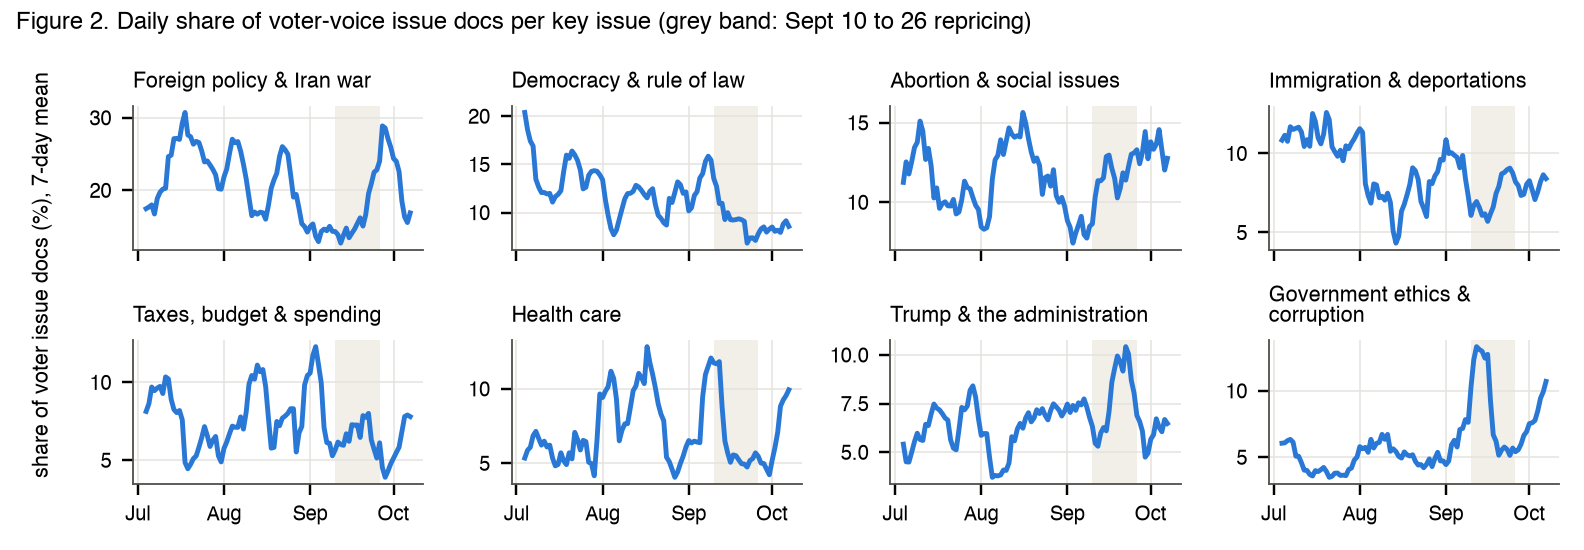

In [5]:
# topic table: every BERTopic topic with its LLM label, top words, share of all docs and one example
from src.config import LABELS
tt = pd.read_csv(LABELS / 'topic_taxonomy.csv').merge(pd.read_csv(LABELS / 'topic_sheet.csv'), on='topic')
tt['share_all_docs_%'] = (100 * tt['n_docs'] / len(pd.read_parquet('data/interim/doc_topics.parquet'))).round(2)
pd.set_option('display.max_colwidth', 120)
display(tt[['topic', 'label', 'short_name', 'confidence', 'share_all_docs_%', 'top_words', 'example_1']].sort_values(['label', 'share_all_docs_%'], ascending=[True, False]))
display((pd.read_csv(TABLES / 'q1_issue_shares.csv', index_col=0) * 100).round(1))
display(pd.read_csv(TABLES / 'q1_poll_compare.csv').round(2))
display((pd.read_csv(TABLES / 'q1_seed_stability.csv', index_col=0) * 100).round(1))
for f in ['fig1_issue_shares.png', 'fig2_salience_over_time.png']:
    display(Image(filename=str(FIGURES / f), width=950))

**How these figures are made (Q1).** Every doc has a BERTopic topic (or -1, an outlier). The LLM taxonomy (`data/labels/topic_taxonomy.csv`) maps each of the 61 topics to an issue, horse race, media or noise. Figure 1 takes the voter-voice social docs (comments, self-posts, non-media tweets) dated Jul 1 to Oct 7 whose topic is an issue, and divides the count per issue by the count over all issues; the news bars do the same for election headlines; the green bars are the Reuters/Ipsos percentages. Figure 2 is the same share computed day by day, with a 7-day mean. No sentiment score is used in either, and both are descriptive, not predictions.

## 5. Q2: A module that measures sentiment on those issues over time

*Readings used:* Carvalho and Plastino (2020), Psomakelis et al. (2014) and the autism-awareness slides on why tools disagree and need validation; Souza et al. (2015) for daily sentiment series.

![Figure 3](outputs/figures/fig3_directional_index.png)
*Figure 3. Directional index per key issue and the composite C (7-day means). Each issue's line is the source-weighted mean direction score (NLI for tweets, target-signed RoBERTa for Reddit), demeaned within issue and source, so 0 is that issue's own window average and + means more pro-Democrat or anti-GOP than usual. Grey band: the Sept 10 to 26 repricing. Descriptive.*

**Result.** Partly. The module is built and validated: per document it gets direction right well above chance (macro-F1 0.59, κ 0.38 overall; 0.59 on tweets with NLI, 0.58 on Reddit with target-signed RoBERTa), and the composite uses 18,831 voter docs (median 189 a day; every key issue has 5+ docs on 94% to 100% of days). But **as a daily series it is mostly noise**: splitting each day's posts at random into two halves 50 times, the half-composites correlate at r = 0.08 on average (range -0.05 to 0.22; Spearman-Brown 0.15). Its versions agree with each other (r 0.94 equal weights, 0.99 expanding weights, 0.80 all social posts, 0.75 the 20-doc minimum, 0.71 RoBERTa only) and differ from plain tone (r = -0.22). It hardly trends (mean 0.001 in the first half, -0.002 in the second; sd 0.038).

*Against the class readings:* as in the tool-comparison papers, tools disagree and the lexicon (VADER) is last for direction and tone.

*Why this result:* direction is harder than tone (macro-F1 0.59 vs 0.71), and only about 189 posts a day reach the index, split over 8 issues and 7 sources, so the median non-empty cell has 3 posts. Most political posting is partisans repeating their side, so who posts that day moves the mean more than any shift in mood; demeaning by source removes the fixed lean, not that daily noise.

**In short.** The directional module works per post and is honest about which tool is used where, but at a daily horizon it carries little signal (split-half r 0.08), which sets a low ceiling for Q3 and Q4.

docs in index: 18831 | median docs/day: 189.0
coverage (share of days with >= 5 docs): {'Foreign policy & Iran war': 1.0, 'Democracy & rule of law': 1.0, 'Abortion & social issues': 1.0, 'Immigration & deportations': 1.0, 'Taxes, budget & spending': 0.99, 'Health care': 0.939, 'Trump & the administration': 1.0, 'Government ethics & corruption': 0.97}
split-half reliability: {'r_level_mean': 0.07907720752653359, 'r_level_sd': 0.07257872184580393, 'r_level_min': -0.05222710786008132, 'r_level_max': 0.22284533881348315, 'r_change_mean': 0.11887576013123075, 'sb_level_of_mean': 0.14656450340155877, 'n_seeds': 50}
correlation of C with its alternatives: {'C': 1.0, 'C_equal_w': 0.935, 'C_pooled': 0.787, 'C_all_social': 0.796, 'C_rob_tgt_only': 0.706, 'C_tone_nondirectional': -0.217, 'C_expanding_w': 0.994, 'C_min20_prereg': 0.75}


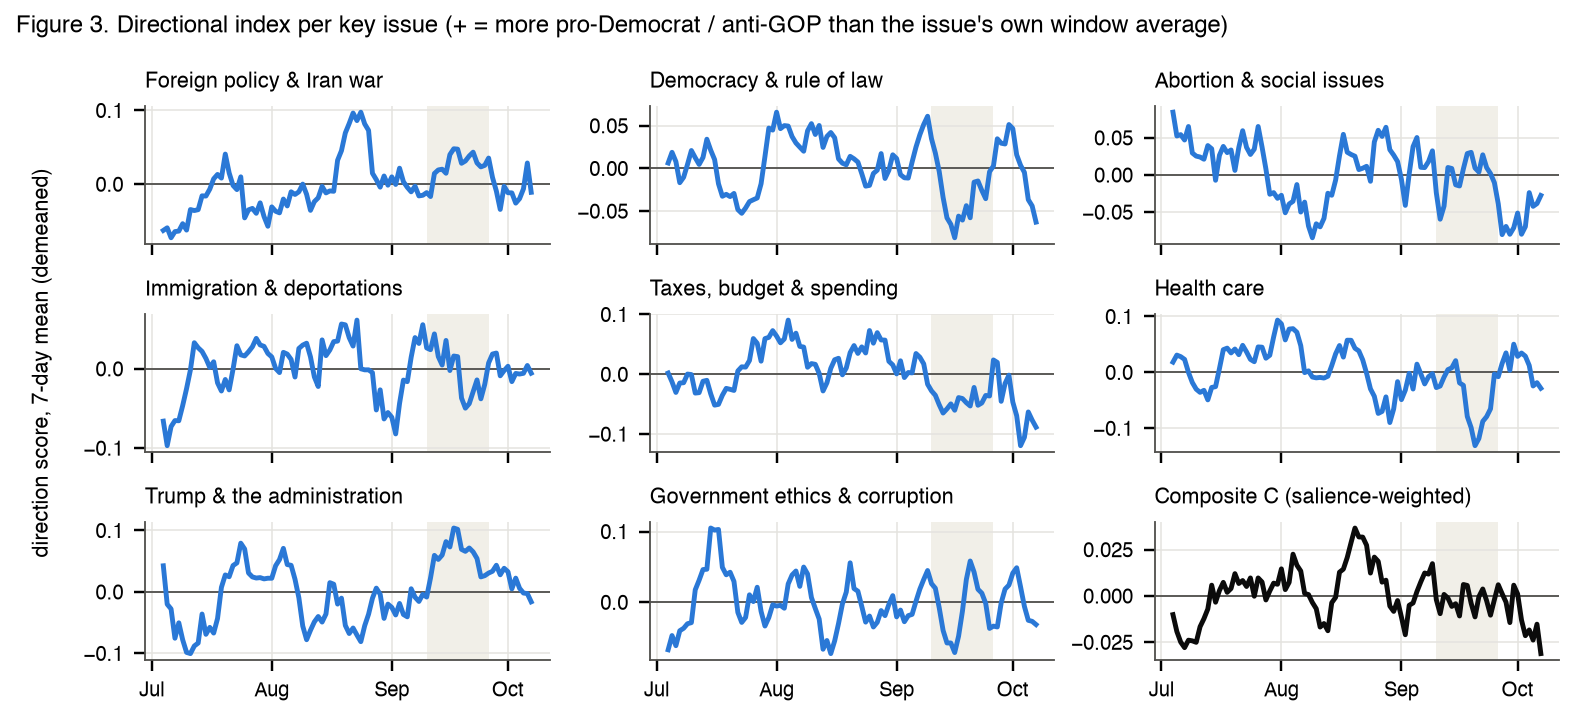

In [6]:
print('docs in index:', R['q2']['docs_in_index'], '| median docs/day:', R['q2']['docs_per_day_median'])
print('coverage (share of days with >= 5 docs):', R['q2']['coverage_ge5'])
print('split-half reliability:', R['q2']['split_half'])
print('correlation of C with its alternatives:', R['q2']['corr_C_with_alternatives'])
display(Image(filename=str(FIGURES / 'fig3_directional_index.png'), width=950))

**How this figure is made (Q2).** Each voter doc gets a direction score: NLI s = P(pro-D) - P(pro-R) for tweets, (P_pos - P_neg) x tau for Reddit. For each key issue, source (Twitter and each subreddit) and day, the mean score is demeaned within that issue and source, then the sources are combined with fixed weights (their share of docs over the window). That gives the issue lines. The composite C weights the 8 issues by their Q1 voter shares. Lines are 7-day means; the tests use the daily values. Descriptive.

## 6. Q3: Does issue sentiment move with the probability of a Democratic sweep?

*Readings used:* Souza et al. (2015) for testing both directions and reporting each lag. External: Snowberg, Wolfers and Zitzewitz (2007) on using prediction-market prices as probabilities.

![Figure 4](outputs/figures/fig4_sweep_index.png)
*Figure 4. (a) P(Democratic sweep) at 16:00 ET, Polymarket and Kalshi bid/ask mid. (b) Composite C, daily and 7-day mean, in its own panel (no second axis). (c) corr(C_t-j, ΔP_t), Polymarket; dashed lines are ±1.96/√N. Grey band: the Sept 10 to 26 repricing. Panels (a) and (b) are descriptive; (c) is the lead-lag test, not a prediction.*

**Result.** No. The sweep odds rose from 42.5% (Jul 1) to 63.5% (Oct 7), with a peak of 66.5% on Oct 4 and most of the move in Sept 13 to 23, but the index does not move with them. C is stationary (ADF p < 0.001, KPSS p ≥ 0.10), so by the pre-set rule its level is tested against ΔP (the odds level has a unit root, ADF p = 0.97).

**Table 4. Family A, C_t vs ΔP_t (Polymarket), N = 96 to 99 days**

| Test | Lag | Pearson r / sum of coefs | HAC p | Permutation p | BH q |
|---|---|---|---|---|---|
| Same day | 0 | r = 0.067 | 0.58 | 0.53 | 0.68 |
| C → ΔP | 1 / 2 / 3 | -1.07 / -6.84 / -6.79 | 0.69 / 0.06 / 0.09 | 0.74 / 0.13 / 0.17 | 0.69 / 0.31 / 0.31 |
| ΔP → C | 1 / 2 / 3 | -0.002 / -0.006 / -0.010 | 0.56 / 0.58 / 0.14 | 0.63 / 0.59 / 0.30 | 0.68 / 0.68 / 0.32 |

- **No test passes the claim rule** (none has q < 0.10). The same-day r of 0.067 is well below what 99 days can detect (r* = 0.28).
- The lowest p-values (C → ΔP, lags 2 and 3) have the **opposite** sign: a more pro-D day goes with slightly lower odds two days later; the VAR(3) impulse response agrees at day 2 (-0.20 points, 90% band -0.38 to -0.01). In the robustness grid 18 of 86 tests have p < 0.10, all with a negative sign; when every index series is circularly shifted to break its link with ΔP, the grid gives 15.8 such hits on average (18 or more 37% of the time), so the count is what chance gives. The strongest hit, trading-day ΔP → C at lag 3 (p = 0.002, within-spec q = 0.016), also has the wrong sign. With the pre-registered 20-doc minimum the lag-2 pattern disappears (p = 0.95), and the secondary test in changes (ΔC vs ΔP) is null (r = 0.069, smallest p 0.11).
- The ceiling is low anyway: Polymarket and Kalshi daily changes correlate at only 0.40, and the odds do not move on 57% of days.

*Against Souza et al.:* they find Twitter sentiment Granger-causes some retail stocks' returns at a 1-day lag; here neither direction works at lag 1, and the lag-2 pattern has the wrong sign.

*Why this result:* the repricing coincided with polls (NYT/Siena Sept 15, state Senate polls), a ratings change (Cook, Sept 23) and high gas prices ($4.48 on Sept 24), which traders read directly, while posters argue about the same war and courts every day. A noisy index (Q2) against odds that move in steps on few days leaves little room for a daily link.

**In short.** Text sentiment on the key issues did not lead or follow the sweep odds at a daily horizon; the one pattern is fragile and wrong-signed, and the test had little power to begin with.

stationarity: {
 "C": {
  "N": 99,
  "ADF_p": 3.701827469857301e-20,
  "KPSS_p": 0.1,
  "stationary": true
 },
 "dC": {
  "N": 98,
  "ADF_p": 1.6480240662049446e-11,
  "KPSS_p": 0.1,
  "stationary": true
 },
 "p_level": {
  "N": 99,
  "ADF_p": 0.9678216555897823,
  "KPSS_p": 0.01,
  "stationary": false
 },
 "dP": {
  "N": 99,
  "ADF_p": 3.2793495773227916e-14,
  "KPSS_p": 0.1,
  "stationary": true
 }
}


,spec,test,direction,lag,N,pearson_r,spearman_r,coef,p_hac,p_perm,p_F,q_bh
0,primary: C vs dP Polymarket,same-day,sent ~ dP,0,99,0.0673,0.0311,1.3954,0.5755,0.5349,NaN,0.6792
1,primary: C vs dP Polymarket,granger,sent -> dP,1,98,NaN,NaN,-1.0688,0.6925,0.7442,0.6887,0.6925
2,primary: C vs dP Polymarket,granger,dP -> sent,1,98,NaN,NaN,-0.0021,0.5620,0.6279,0.6249,0.6792
3,primary: C vs dP Polymarket,granger,sent -> dP,2,97,NaN,NaN,-6.8363,0.0592,0.1279,0.1335,0.3129
4,primary: C vs dP Polymarket,granger,dP -> sent,2,97,NaN,NaN,-0.0056,0.5822,0.5930,0.5686,0.6792
5,primary: C vs dP Polymarket,granger,sent -> dP,3,96,NaN,NaN,-6.7913,0.0894,0.1744,0.2414,0.3129
6,primary: C vs dP Polymarket,granger,dP -> sent,3,96,NaN,NaN,-0.0097,0.1382,0.3023,0.3915,0.3225


claim checks: [{'test': 'same-day', 'direction': 'sent ~ dP', 'lag': 0, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'sent -> dP', 'lag': 1, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'dP -> sent', 'lag': 1, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'sent -> dP', 'lag': 2, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'dP -> sent', 'lag': 2, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'sent -> dP', 'lag': 3, 'pre_checks_pass': False}, {'test': 'granger', 'direction': 'dP -> sent', 'lag': 3, 'pre_checks_pass': False}]


,spec,test,direction,lag,N,pearson_r,spearman_r,coef,p_hac,p_perm,p_F,q_bh
2,Kalshi mid,granger,dP -> sent,1,98,NaN,NaN,-0.0044,0.0934,NaN,0.2406,0.2701
3,Kalshi mid,granger,sent -> dP,2,97,NaN,NaN,-5.3565,0.0870,NaN,0.1611,0.2701
10,venue average,granger,sent -> dP,2,97,NaN,NaN,-5.9430,0.0182,NaN,0.0585,0.1090
12,venue average,granger,sent -> dP,3,96,NaN,NaN,-7.7144,0.0311,NaN,0.1054,0.1090
17,dlogit Polymarket,granger,sent -> dP,2,97,NaN,NaN,-0.2807,0.0564,NaN,0.1299,0.2971
19,dlogit Polymarket,granger,sent -> dP,3,96,NaN,NaN,-0.2759,0.0849,NaN,0.2330,0.2971
30,C_equal_w,granger,dP -> sent,1,98,NaN,NaN,-0.0063,0.0842,NaN,0.1486,0.1614
31,C_equal_w,granger,sent -> dP,2,97,NaN,NaN,-6.8430,0.0571,NaN,0.0995,0.1614
33,C_equal_w,granger,sent -> dP,3,96,NaN,NaN,-6.9999,0.0922,NaN,0.1604,0.1614
34,C_equal_w,granger,dP -> sent,3,96,NaN,NaN,-0.0138,0.0355,NaN,0.2450,0.1614


robust p<0.10: 18 of 86 | detectable r: 0.278 | venue daily corr: 0.397 | venue gap: {'min': -1.0000000000000009, 'max': 6.000000000000005, 'mean': 1.6565656565656577}
VAR impulse response of dP to an index shock: [0.066, -0.067, -0.199, -0.06, -0.028, -0.012, -0.006, -0.007]


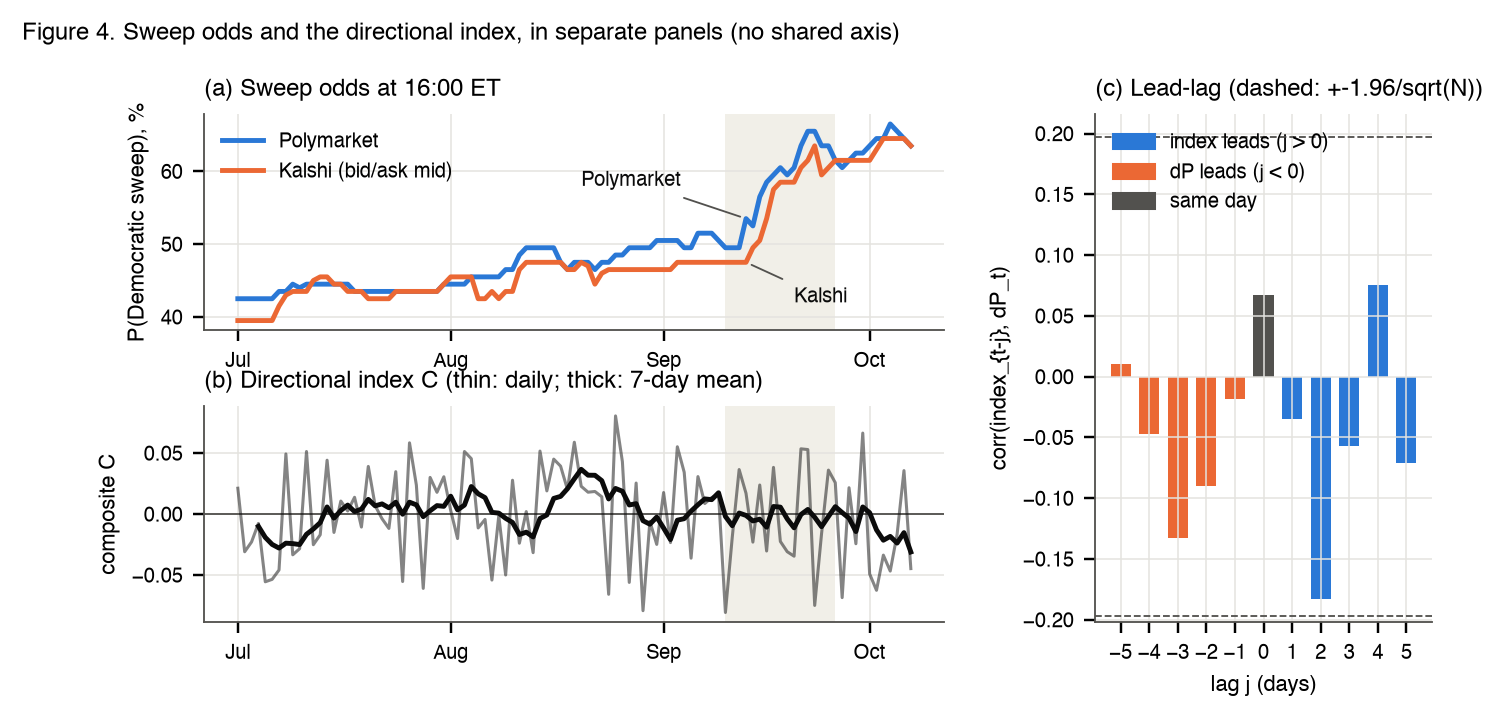

In [7]:
print('stationarity:', json.dumps(R['q3']['stationarity'], indent=1))
display(pd.read_csv(TABLES / 'q3_family_a.csv').round(4))
print('claim checks:', R['q3']['claims'])
g = pd.read_csv(TABLES / 'q3_robustness_grid.csv'); display(g[g.p_hac < 0.10].round(4))
print('robust p<0.10:', R['q3']['robust_count_p_lt_0.10'], 'of', R['q3']['robust_tests'], '| detectable r:', round(R['q3']['mde_r_N'], 3),
      '| venue daily corr:', round(R['q3']['venue_daily_corr'], 3), '| venue gap:', R['q3']['venue_gap_pp'])
print('VAR impulse response of dP to an index shock:', [round(x, 3) for x in R['q3']['var']['irf_dP_to_sent_shock']])
display(Image(filename=str(FIGURES / 'fig4_sweep_index.png'), width=950))

**How this figure is made (Q3).** Panel (a) is the last hourly price at or before 16:05 ET each day (Polymarket's price; Kalshi's bid/ask mid). Panel (b) is the daily composite C from Q2 in its own panel, so there is no second y-axis. Panel (c) is the correlation of C shifted by j days with the daily change in the Polymarket price; blue bars (j > 0) are the index leading, orange bars the odds leading. It is a test, not a prediction.

## 7. Q4: Which stocks are exposed, and does the basket move with sentiment?

*Readings used:* Rigobon and Sack (2003), the class reading on how a political risk moves asset prices, with Rigobon (2003) for the identification idea. External: MacKinlay (1997), Knight (2006), Snowberg et al. (2007).

**Table 5. The mid-term basket (signs fixed before any test-window data; γ = % abnormal return per +1 point of P(sweep), Aug 2025 to Jun 2026, N = 229)**

| Leg | Group: names | Why a sweep matters with a Republican veto | Pre-window γ (group, pooled) |
|---|---|---|---|
| Long | ACA/Medicaid insurers: OSCR, CNC, MOH | enhanced ACA credits expired Dec 31, 2025; the House passed a 3-year extension that died in the Senate | +0.36 |
| Long | Hospitals: HCA, THC, UHS, CYH | all report exchange-loss hits (HCA $1.0 to 1.2B); HCA, UHS and CYH cut 2026 guidance | +0.14 |
| Long | Guns: RGR, SWBI | fear buying: +12% and +18% the day the 2021 Georgia runoffs gave D the Senate | +0.23 |
| Short | Detention: GEO, CXW | ICE was 47.6% of GEO's and 35% of CXW's 2025 revenue; future money needs Congress | +0.07 |
| Short | Defense: LMT, NOC, GD, HII | $350B of the $1.5T FY27 request depends on a GOP reconciliation bill | -0.01 |
| Short | Crypto: COIN, HOOD | the CLARITY Act failed cloture on Sept 15 with no Democratic votes | +0.14 |

Oil, clean energy and tariff retail (10 names) form a separate "weak" sub-basket: the lever is already fixed by statute or executive action (leases mandated to 2039, credits ended, tariffs under Sections 301 and 232). Pharma and banks are out: both parties push drug prices, and capital rules come from regulators. Pre-window: long leg γ = +0.24 (SE 0.12, p = 0.055), all 9 long names with the expected sign (CNC and MOH clear of zero); short leg +0.05 (p = 0.53); long minus short +0.18 (p = 0.21).

![Figure 5](outputs/figures/fig5_basket.png)
*Figure 5. (a) Cumulative market-adjusted return of the equal-weighted long leg, short leg and long minus short, AR = r - β x SPY, β from Aug 2025 to Jun 2026. (b) Polymarket P(sweep) in its own panel. Grey band: the Sept 10 to 26 repricing. Descriptive; the tests are in the text.*

**Result.** Partly. Over the window long minus short gained **+6.3%** market-adjusted (long +3.4%, short -2.9%; +4.3% against sector factors) while the odds rose 21 points, but day by day it does not move with them: slope on ΔP 0.05 (SE 0.16, r = 0.03) on Polymarket, 0.17 (p = 0.22) on Kalshi. The Rigobon and Sack estimate, from the 12 repricing days (ΔP variance 5.0 times higher), is +0.34 per point, 95% CI -0.61 to 1.24 (0.31 without the Fed-hike day; these high days were picked from the odds, not from dated news as in their paper). Against the sentiment index (trading days, N = 66 to 69) no family-A test passes (smallest BH q 0.40), and the 8 of 49 robustness hits are fewer than a shifted null gives (10.4); within its own spec, the factor-adjusted weak basket leads sentiment (q = 0.073, positive).
- The basket's moves are dominated by single names (THC +30%, CYH -26%, MOH -15% market-adjusted over the window) and by sectors. The weak sub-basket lost 41% market-adjusted but only 8% against its sector factors, because the oil names rose with oil (USO +35%) and clean energy fell with ICLN (-15.5%).
- Per name (BH over 27), only RUN (+0.82 per point, q = 0.002, expected sign) and DLTR (-0.62, q = 0.002, opposite sign) move with ΔP, both in the weak sub-basket; the insurers and hospitals do not (slopes -0.23 to +0.31), so the test window does not confirm their pre-window γ. OSCR's sign is unclear (it gained ACA members); without it the basket made +5.8%.

*Against Rigobon and Sack:* they find war risk lowers equities and raises oil prices, identified from war-news days on which the war factor's variance is higher. Our high-news days also carry 5 times the variance of ΔP, but the response of this basket is too noisy to sign. *Against Knight (2006):* he finds clear firm-level effects in 2000 (tobacco +13%, alternative energy -16% on Bush's odds); our pre-window long leg fits that, the test window does not.

*Why this result:* with a Republican veto a sweep changes few laws, so the effect per point of probability is small, and 69 days of single-stock noise hide it. The +6.3% is dominated by a few hospital and insurer moves and by defense names falling (NOC -7%, GD -10%, HII -10%), so the election part cannot be separated.

**In short.** The basket's direction over the window fits a Democratic sweep, and its long leg had pre-window support, but daily returns are not linked to the odds or to the text index, so the evidence that these stocks trade on the election is weak.

,group,expected_sign,beta,gamma_coef,gamma_se,gamma_ci90_lo,gamma_ci90_hi,sign_match
ticker,,,,,,,,
GEO,detention,-1,0.854,0.121,0.204,-0.215,0.456,False
CXW,detention,-1,0.522,0.024,0.152,-0.226,0.275,False
LMT,defense,-1,0.105,0.008,0.089,-0.138,0.155,False
NOC,defense,-1,0.056,0.001,0.075,-0.122,0.125,False
GD,defense,-1,0.434,0.001,0.062,-0.101,0.104,False
HII,defense,-1,0.697,-0.033,0.133,-0.251,0.186,True
COIN,crypto,-1,3.136,0.180,0.181,-0.117,0.477,False
HOOD,crypto,-1,3.041,0.104,0.205,-0.234,0.442,False
OSCR,aca_insurers,1,1.560,0.459,0.287,-0.014,0.931,True


,strength,expected_sign,n_names,gamma,se,t,p,N,sign_match
group,,,,,,,,,
detention,strong,-1,2,0.072,0.163,0.445,0.656,458,False
defense,strong,-1,4,-0.005,0.079,-0.069,0.945,916,True
crypto,strong,-1,2,0.142,0.163,0.871,0.384,458,False
aca_insurers,strong,1,3,0.358,0.213,1.678,0.093,687,True
hospitals,strong,1,4,0.145,0.117,1.242,0.214,916,True
guns,strong,1,2,0.233,0.206,1.131,0.258,458,True
oil_gas,weak,-1,3,0.083,0.089,0.936,0.349,687,False
clean_energy,weak,1,4,0.054,0.188,0.288,0.774,916,True
tariff_retail,weak,1,3,0.046,0.116,0.398,0.691,687,True


,coef,se,t,p,N,ci90_lo,ci90_hi
strong_ls,0.184,0.148,1.243,0.214,229.0,-0.060,0.428
strong_long,0.235,0.123,1.918,0.055,229.0,0.034,0.437
strong_short,0.051,0.080,0.636,0.525,229.0,-0.081,0.183
weak_ls,-0.033,0.182,-0.179,0.858,229.0,-0.332,0.267
strong_ls_no_OSCR,0.157,0.145,1.082,0.279,229.0,-0.081,0.395


,basket,leg,venue,coef,se,t,p_hac,N,pearson_r
0,strong,ls,poly_p,0.049,0.163,0.297,0.767,69,0.031
1,strong,ls,kal_p,0.167,0.135,1.232,0.218,69,0.119
2,strong,ls,avg_p,0.150,0.175,0.856,0.392,69,0.089
9,weak,ls,poly_p,0.216,0.196,1.103,0.270,69,0.101
10,weak,ls,kal_p,0.170,0.243,0.702,0.483,69,0.088
11,weak,ls,avg_p,0.252,0.227,1.107,0.268,69,0.108
18,strong_noOSCR,ls,poly_p,0.059,0.177,0.332,0.740,69,0.037
19,strong_noOSCR,ls,kal_p,0.153,0.142,1.073,0.283,69,0.106
20,strong_noOSCR,ls,avg_p,0.146,0.187,0.780,0.435,69,0.084
27,strong_factor,ls,poly_p,0.026,0.188,0.138,0.890,69,0.019


,d,var_shift,N_H,N_L,ci95_lo,ci95_hi,var_ratio_H_over_L
strong,0.344,2.543,12.0,57.0,-0.609,1.244,5.025
weak,0.512,2.543,12.0,57.0,-0.889,2.768,5.025
strong_factor,0.333,2.543,12.0,57.0,-0.692,1.375,5.025
weak_factor,0.195,2.543,12.0,57.0,-0.622,1.650,5.025
strong_long,0.082,2.543,12.0,57.0,-0.619,0.734,5.025
strong_short,-0.262,2.543,12.0,57.0,-1.102,0.420,5.025
strong_drop_Sep16,0.310,2.768,11.0,57.0,-0.523,1.229,5.382


,spec,test,direction,lag,N,pearson_r,spearman_r,coef,p_hac,p_perm,p_F,q_bh
0,sentiment vs strong L/S AR (trading days),same-day,sent ~ LS,0,69,-0.0152,0.0016,-4.1616,0.4860,0.8929,NaN,0.5670
1,sentiment vs strong L/S AR (trading days),granger,sent -> LS,1,68,NaN,NaN,-6.0540,0.2048,0.2321,0.2748,0.4015
2,sentiment vs strong L/S AR (trading days),granger,LS -> sent,1,68,NaN,NaN,-0.0021,0.3789,0.4821,0.4868,0.5304
3,sentiment vs strong L/S AR (trading days),granger,sent -> LS,2,67,NaN,NaN,-11.1035,0.1786,0.3214,0.3971,0.4015
4,sentiment vs strong L/S AR (trading days),granger,LS -> sent,2,67,NaN,NaN,-0.0025,0.6745,0.6964,0.7565,0.6745
5,sentiment vs strong L/S AR (trading days),granger,sent -> LS,3,66,NaN,NaN,-8.7150,0.2294,0.4821,0.5707,0.4015
6,sentiment vs strong L/S AR (trading days),granger,LS -> sent,3,66,NaN,NaN,0.0033,0.2077,0.5357,0.5075,0.4015


,ticker,group,expected_sign,test_coef,test_se,test_t,test_p_hac,test_N,pre_gamma,pre_gamma_se,beta_spy,cum_ar_window
0,GEO,detention,-1,-0.160,0.343,-0.466,0.641,69,0.121,0.204,0.854,-0.303
1,CXW,detention,-1,-0.429,0.456,-0.942,0.346,69,0.024,0.152,0.522,2.391
2,LMT,defense,-1,0.113,0.147,0.767,0.443,69,0.008,0.089,0.105,-1.894
3,NOC,defense,-1,0.077,0.130,0.595,0.552,69,0.001,0.075,0.056,-7.097
4,GD,defense,-1,-0.014,0.099,-0.146,0.884,69,0.001,0.062,0.434,-9.539
5,HII,defense,-1,0.113,0.131,0.859,0.390,69,-0.033,0.133,0.697,-9.595
6,COIN,crypto,-1,-0.188,0.328,-0.574,0.566,69,0.180,0.181,3.136,6.683
7,HOOD,crypto,-1,0.103,0.195,0.529,0.597,69,0.104,0.205,3.041,-4.065
8,OSCR,aca_insurers,1,-0.081,0.303,-0.267,0.789,69,0.459,0.287,1.560,7.710
9,CNC,aca_insurers,1,-0.116,0.189,-0.616,0.538,69,0.313,0.166,0.320,-0.084


cumulative AR at Oct 7 (%): {'strong': 6.342, 'weak': -41.197, 'strong_noOSCR': 5.805, 'strong_factor': 4.271, 'weak_factor': -7.878, 'gate': 6.885, 'long': 3.415, 'short': -2.927} | provisional Oct 7 close: True


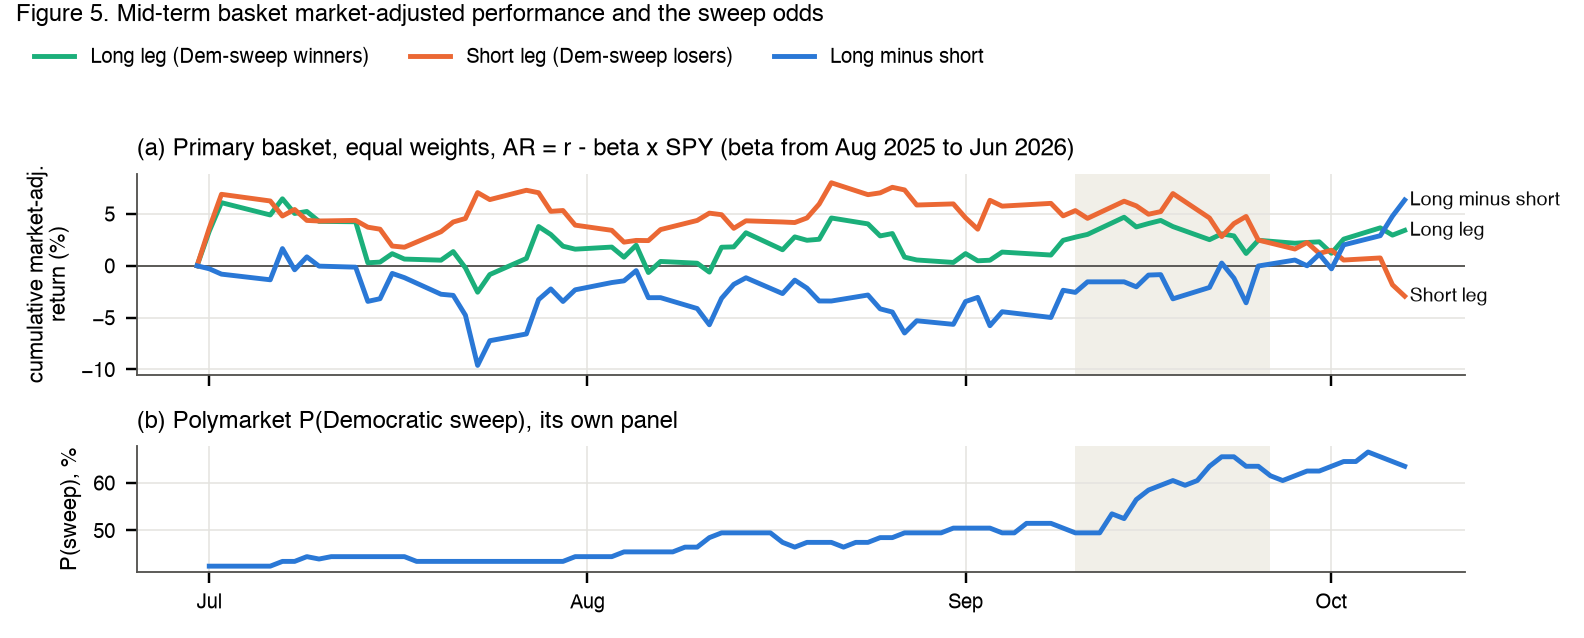

In [8]:
display(pd.read_csv(TABLES / 'q4_election_betas_main_poly.csv', index_col=0)[['group', 'expected_sign', 'beta', 'gamma_coef', 'gamma_se', 'gamma_ci90_lo', 'gamma_ci90_hi', 'sign_match']].round(3))
display(pd.read_csv(TABLES / 'q4_group_gamma_main_poly.csv', index_col=0).round(3))
display(pd.read_csv(TABLES / 'q4_basket_gamma_main_poly.csv', index_col=0).round(3))
v = pd.read_csv(TABLES / 'q4_validation_vs_dp.csv'); display(v[v.leg == 'ls'].round(3))
display(pd.read_csv(TABLES / 'q4_rigobon_sack.csv', index_col=0).round(3))
display(pd.read_csv(TABLES / 'q4_family_sent_vs_basket.csv').round(4))
display(pd.read_csv(TABLES / 'q4_per_name.csv').round(3))
print('cumulative AR at Oct 7 (%):', R['q4']['cum_ar_end'], '| provisional Oct 7 close:', R['q4']['provisional_oct7'])
display(Image(filename=str(FIGURES / 'fig5_basket.png'), width=950))

**How this figure is made (Q4).** For each name, beta on SPY comes from daily log returns Aug 1, 2025 to Jun 30, 2026. In the test window AR = 100 x (r - beta x r_SPY), with no alpha. The long leg is the equal-weighted mean AR of the 9 names expected to gain from a sweep, the short leg of the 8 expected to lose, and the lines are cumulative sums from 0 on Jun 30. Panel (b) is the Polymarket price in its own panel. Descriptive.

## 8. Q5: What I conclude

*Readings used:* all of the above; the numbers are from Sections 4 to 7.

1. **Voters' agenda is not the polls' agenda.** In 12,567 voter issue posts, foreign policy (mostly Israel and the Iran war) is 20.3% and the economy 6.2% (6% to 9% across seeds), the reverse of every poll (economy 22% to 31%). Robust for the top two (foreign policy, democracy) over all seeds and weightings; the order below them is fragile (abortion and social issues 3% to 11% depending on the seed). For a PM, issue polls and social text answer different questions; text tells you what is being argued about this week.
2. **Media cover a different agenda again.** In 23,045 election headlines the economy is 14.8% and markets or tech 17.9%, but social issues only 2.8% (voters 11.5%, a fragile share). Robust across outlet groups: every group is further from voters than voters' own shared links are (E1).
3. **A directional political-sentiment index can be built and validated (macro-F1 0.59), but daily it is mostly noise** (split-half r 0.08, 189 docs a day). Do not trade on a daily political mood index of this size.
4. **No daily link between sentiment and the sweep odds** (0 of 7 pre-registered tests pass; r = 0.067 vs a detectable 0.28). The low p-values have the wrong sign, vanish under the pre-registered 20-doc minimum, and their count is no more than chance (joint shifted null P = 0.37). Correlation and Granger tests are not causality in any case.
5. **The mid-term basket moved the right way (+6.3%) but is not a clean election trade.** Over 69 trading days its daily link to the odds is nil (r = 0.03), the heteroskedasticity estimate is not signed (CI -0.61 to 1.24), and no insurer or hospital confirmed its pre-window γ. Fragile. If a PM wants election exposure, the pre-window evidence pointed to ACA insurers and hospitals rather than defense or detention, but the test window did not confirm it; with a Republican veto, the stakes per point of sweep probability are small.

**In short.** What voters talk about is measurable and different from what polls and media show, but a daily political mood index of this size does not move with the sweep odds or with the stocks the result would affect; the long-run fit of the basket is suggestive at best.

## 9. Extra questions that came up

*Readings used:* Sacerdote et al. (2020) for E1; Rigobon and Sack (2003) for the event window in E3.

**E1. Do media and voters care about the same issues?**
*Result:* no, and business media differ most. Agenda distance from voters (TVD; 0 = same, 1 = no overlap): voters' shared links 0.16, all news 0.27, US left 0.21, US right 0.21, US centre 0.28, international 0.29, business 0.51. Right-leaning outlets rank issues closest to voters (Spearman 0.75; left 0.65, business 0.50), and the economy's share rises from voters (6.2%) to right (8.2%), left (9.9%), centre (16.0%) and business outlets (26.9%).
*Why this result:* likely, partisan outlets cover the same fights partisans post about (Iran, courts, immigration), while business media cover prices, rates and markets. As in Sacerdote et al., the outlet group shapes what you see, here in what is covered rather than how negative it is.
*In short:* the further an outlet is from partisan politics, the further its agenda is from voters'.

**E2. Which single issue tracks the sweep odds most?** *Result:* none; over 8 issues x 3 tests (BH over 24) the smallest q is 0.57 (largest same-day slope: "Trump and the administration", p = 0.14). *Why this result:* each issue's daily index has even fewer docs than the composite. *In short:* splitting by issue finds no hidden link.

**E3. What happened during the Sept 10 to 26 repricing?**
*Result:* the odds rose 11 points in these 17 days, and voters' attention shifted (vs Aug 24 to Sept 9): up for foreign policy (+4.0 points of issue share), economy (+3.5), social issues (+3.1) and ethics (+2.7); down for democracy (-4.9), tariffs (-4.3) and health care (-3.6). But the directional index did not turn pro-Democrat (mean 0.002 before, -0.003 during).
*Why this result:* the repricing coincided with polls and a ratings change, which traders watch; posters' attention moved, but each side kept its view. *In short:* the repricing shows up in what people talk about, not in which side they favour.

In [9]:
display(pd.read_csv(TABLES / 'e1_agenda_distance.csv').round(3))
display(pd.read_csv(TABLES / 'e2_issue_vs_sweep.csv').round(3))
display((pd.read_csv(TABLES / 'e3_issue_shift.csv', index_col=0)).round(4))
print({k: v for k, v in R['extras']['e3'].items() if k != 'xcorr_event'})

,group,tvd_vs_voter,spearman_vs_voter,economy_share,iran_share
0,shared_media,0.163,0.779,0.057,0.246
1,news,0.268,0.623,0.148,0.233
2,news_US_LEFT,0.207,0.652,0.099,0.234
3,news_US_RIGHT,0.212,0.753,0.082,0.294
4,news_US_CENTER,0.276,0.599,0.160,0.235
5,news_BUSINESS,0.512,0.502,0.269,0.169
6,news_INTL,0.287,0.588,0.144,0.288


,issue,same_day_coef,same_day_p_hac,N,granger_sent_to_dP_p_hac,granger_dP_to_sent_p_hac,same_day_q,g_sent_dP_q,g_dP_sent_q
0,Foreign policy & Iran war,-0.283,0.783,99,0.387,0.101,0.854,0.663,0.570
1,Democracy & rule of law,1.065,0.304,99,0.484,0.500,0.663,0.667,0.667
2,Abortion & social issues,0.397,0.701,99,0.190,0.177,0.801,0.570,0.570
3,Immigration & deportations,0.500,0.428,99,0.939,0.111,0.663,0.939,0.570
4,"Taxes, budget & spending",-0.084,0.930,99,0.159,0.403,0.939,0.570,0.663
5,Health care,-0.690,0.331,99,0.442,0.088,0.663,0.663,0.570
6,Trump & the administration,1.488,0.145,99,0.379,0.624,0.570,0.663,0.748
7,Government ethics & corruption,-0.433,0.574,99,0.403,0.062,0.725,0.663,0.570


,pre_mean_share,event_mean_share,change_pp
Foreign policy & Iran war,0.1466,0.1862,3.9536
Economy & cost of living,0.0764,0.1113,3.4825
Abortion & social issues,0.0930,0.1244,3.1460
Government ethics & corruption,0.0591,0.0859,2.6847
Tech & AI,0.0551,0.0811,2.5944
Trump & the administration,0.0694,0.0784,0.8946
Crime & policing,0.0033,0.0010,-0.2294
Education,0.0135,0.0101,-0.3328
Guns,0.0152,0.0119,-0.3345
"Taxes, budget & spending",0.0786,0.0645,-1.4138


{'C_pre_mean': 0.0019329243253320449, 'C_event_mean': -0.0028554623881795285, 'dP_event_sum_pp': 10.999999999999998, 'dP_pre_sum_pp': 3.0000000000000027}


## 10. Limitations

- **Sample.** Twitter is a paid sample of engaged tweets (16 snapshots a day; 7 empty windows incl. 9 hours on Aug 31); Reddit is six political subs, some heavily moderated (r/Conservative comments 64% removed); news is capped at 100 items per outlet-day and dated only. None of it samples registered voters. **Measurement.** 40% of docs are topic outliers; the taxonomy and all validation labels come from Claude subagents, not humans (inter-labeller κ 0.96 between two subagents, which may share biases); the index needed a disclosed deviation (5 docs per issue-day instead of 20). The topic model and the distilled classifier saw the whole window's text, but never prices.
- **Power and causality.** 99 days (69 trading days) can only detect r ≥ 0.28 (0.33); the tools were chosen and scored on the same 150 items; Granger and correlation are not causality; confounders include the Fed hike (Sept 16), the Iran war's oil effect and company earnings. No election-day test, because the report is due before Nov 3; the Oct 7 stock close is from the last hourly bar.

<p class="refs"><strong>References.</strong> Class readings: Bybee, Kelly, Manela and Xiu (2024), JF 79(5) · Rigobon and Sack (2003), NBER WP 9609 · Rigobon (2003), REStat 85(4) · Souza, Kolchyna, Treleaven and Aste (2015) · Sacerdote, Sehgal and Cook (2020), NBER WP 28110 · Carvalho and Plastino (2020), AI Review · Psomakelis et al. (2014), KDIR · autism-awareness tool-comparison slides; Bagheri; Yener (2020). External: Knight (2006), JPubE 90(4-5) · Snowberg, Wolfers and Zitzewitz (2007), QJE 122(2) · MacKinlay (1997), JEL 35(1) · Grootendorst (2022), arXiv 2203.05794 · Blei, Ng and Jordan (2003), JMLR · Röder, Both and Hinneburg (2015), WSDM · Laurer et al. (2023), arXiv 2312.17543 · Loureiro et al. (2022), TimeLMs · Hutto and Gilbert (2014), ICWSM · Cohen (1960) · Spearman (1910); Brown (1910) · Granger (1969) · Newey and West (1987) · Benjamini and Hochberg (1995) · Said and Dickey (1984); Kwiatkowski et al. (1992) · Hubert and Arabie (1985) · Hulley et al. (2013) · Levin, Peres and Wilmer (2009) · Yuan and Shou (2024), PLOS Biol. Data and facts: Polymarket and Kalshi APIs and rules; twitterapi.io; Arctic Shift; Google News RSS; Pew Research Center (Jul 23, 2026); Gallup MIP (Sept 2026); Reuters/Ipsos (Aug 28 to 31; Sept 17 to 20, 2026); KFF (Oct 6, 2026); company 10-K/10-Q filings (GEO, CXW, CNC); Defense News; Breaking Defense; Newsweek; Fortune; NPR; AP; Federal Reserve (Sept 16, 2026); DOI; IRS.</p>